# Overview & Goals

In this notebook, my main goals are to look at publicly available data and determine:
- average cycle length for women
- average luteal phase length

Follicular phases can vary, and this is what drives cycle variability. Most women have pretty consistent luteal phase lengths. Too short can indicate health problems, too long can indicate pregnancy.

### Imports and Load Data

In [1]:
from os.path import dirname, join as pjoin
import scipy.io as sio
from scipy.io import readsav
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import json

In [2]:
data_path = "../data/FedCycleData071012__2_.sav"

In [3]:
df, meta = pyreadstat.read_sav(data_path)

In [4]:
df.head()

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1.0,0.0,1.0,0.0,29.0,27.33,17.0,12.0,12.0,...,9.0,NaN,NaN,2.0,7.0,7.0,1.0,1.0,0.0,21.254724
1,nfp8122,2.0,0.0,1.0,0.0,27.0,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nfp8122,3.0,0.0,1.0,0.0,29.0,NaN,15.0,14.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,nfp8122,4.0,0.0,1.0,0.0,27.0,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,nfp8122,5.0,0.0,1.0,0.0,28.0,NaN,16.0,12.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns

Index(['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot',
       'ReproductiveCategory', 'LengthofCycle', 'MeanCycleLength',
       'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh',
       'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays',
       'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses',
       'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo',
       'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive',
       'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight',
       'MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11',
       'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay14',
       'MensesScoreDay15', 'TotalMensesScore', 'MeanBleedingIntensity',
       'NumberofDaysofIntercourse', 'IntercourseInFertileWindow',
       'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed',
       'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding

In [6]:
# filter dataset
df_filtered = df[['ClientID', 'CycleNumber', 'LengthofCycle', 'LengthofLutealPhase', 'TotalNumberofHighDays']]

df.shape

(1665, 80)

In [7]:
df_filtered.describe()

,CycleNumber,LengthofCycle,LengthofLutealPhase,TotalNumberofHighDays
count,1665.000000,1665.000000,1514.000000,1653.000000
mean,8.040841,29.299099,13.270806,4.248034
std,6.593686,3.887932,2.671602,3.502879
min,1.000000,18.000000,1.000000,0.000000
25%,3.000000,27.000000,12.000000,2.000000
50%,7.000000,29.000000,13.000000,3.000000
75%,11.000000,31.000000,14.000000,5.000000
max,45.000000,54.000000,41.000000,22.000000


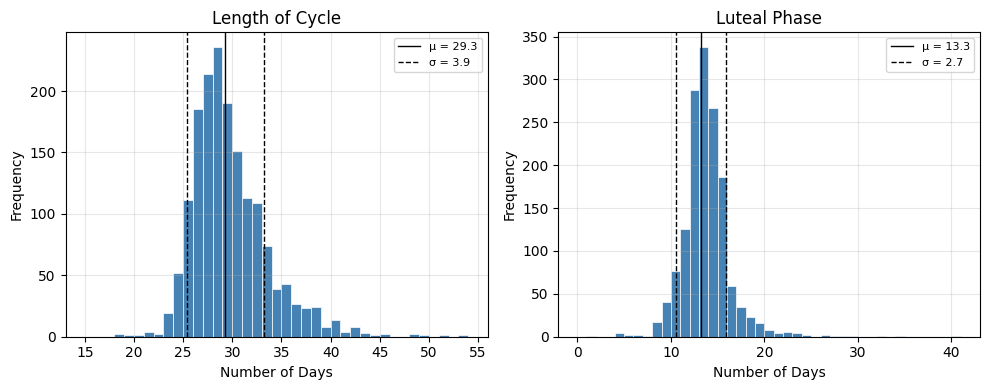

In [8]:
plt.style.use('seaborn-v0_8-muted')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

data = [
    (df['LengthofCycle'], 'Length of Cycle', range(15,55)),
    (df['LengthofLutealPhase'], 'Luteal Phase', range(0,42)),
]

for ax, (series, title, bin_specs) in zip(axes, data):

    s = series.dropna()
    mean, std = s.mean(), s.std()

    ax.hist(s, bins=bin_specs, color='steelblue', edgecolor='white', linewidth=0.5)

    ax.axvline(mean, color='black', linewidth=1., label=f'μ = {mean:.1f}')
    ax.axvline(mean - std, color='black', linewidth=1, linestyle='--', label=f'σ = {std:.1f}')
    ax.axvline(mean + std, color='black', linewidth=1, linestyle='--')
    #ax.axvline(mean - 2*std, color='black', linewidth=1, linestyle=':', label=f'2σ = {2*std:.1f}')
    #ax.axvline(mean + 2*std, color='black', linewidth=1, linestyle=':')

    ax.set_title(title)
    ax.set_xlabel('Number of Days')
    ax.set_ylabel('Frequency')
    ax.grid(which='both', alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../assets/cycle_stats.png')
plt.show()

In [9]:
stats = {
    "luteal": {
        "mean": round(df["LengthofLutealPhase"].mean(), 4),
        "std":  round(df["LengthofLutealPhase"].std(), 4),
        "n":    int(df["LengthofLutealPhase"].dropna().count()),
    },
    "cycle": {
        "mean": round(df["LengthofCycle"].mean(), 4),
        "std":  round(df["LengthofCycle"].std(), 4),
        "n":    int(df["LengthofCycle"].dropna().count()),
    },
}

with open("../data/reference_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print("Saved reference_stats.json")

Saved reference_stats.json
